In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.naive_bayes import GaussianNB  
from sklearn.datasets import load_breast_cancer
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [17]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

In [18]:
X.shape, y.shape

((569, 30), (569,))

<Axes: ylabel='Frequency'>

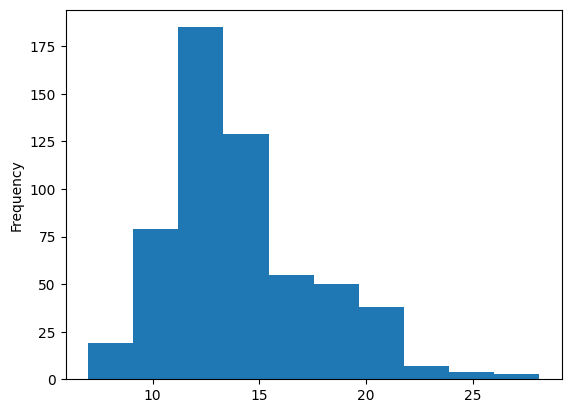

In [19]:
X['mean radius'].plot(kind='hist')

In [20]:
y.unique(), y.value_counts()

(array([0, 1]),
 target
 1    357
 0    212
 Name: count, dtype: int64)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [22]:
len(X_train), len(X_test), len(y_train), len(y_test)

(455, 114, 455, 114)

In [23]:
model = GaussianNB()

In [24]:
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [25]:
print('accuracy on the test set:', round(model.score(X_test, y_test), 4))

accuracy on the test set: 0.9474


In [26]:
# its the same as above (model.score(X_test, y_test))
# We usually use  this structure ( manually i mean )
# 1. Generate the "raw" predictions
y_pred = model.predict(X_test)

# 2. Manually calculate the accuracy (same result as .score)
print(f"Manual Accuracy: {round(metrics.accuracy_score(y_test, y_pred), 4)}")

Manual Accuracy: 0.9474


(array([0, 1]), [Text(0, 0, '0'), Text(0, 1, '1')])

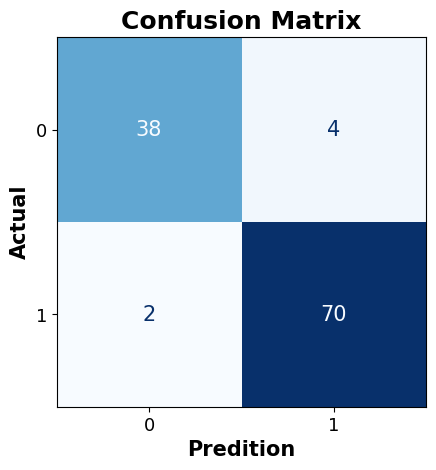

In [27]:
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=model.classes_)
disp.plot(cmap='Blues', colorbar=False, text_kw={'size': 15})
plt.xlabel('Predition', fontsize=15, fontweight='bold')
plt.ylabel('Actual', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

In [29]:
def save_Confusion_Matrix(cm, title, filename):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['1', '0'],
                yticklabels=['1', '0'])
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig(filename)
    plt.close()

cm_sklearn = [[38, 4], [2, 70]]
save_Confusion_Matrix(cm_sklearn, 'Scikit-Learn GNB', 'sklearn_cm.png')

In [30]:
print('Acurracy Score: ',metrics.accuracy_score(y_test, y_pred), end='\n\n')
print('Confusion Matrix: ',metrics.confusion_matrix(y_test, y_pred), end='\n\n')
print('Recall Score: ',metrics.recall_score(y_test, y_pred), end='\n\n')
print('Precision Score: ',metrics.precision_score(y_test, y_pred), end='\n\n')
print('F1 Score: ',metrics.f1_score(y_test, y_pred), end='\n\n')

Acurracy Score:  0.9473684210526315

Confusion Matrix:  [[38  4]
 [ 2 70]]

Recall Score:  0.9722222222222222

Precision Score:  0.9459459459459459

F1 Score:  0.958904109589041



In [31]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
# %%writefile requirements.txt
# pandas==3.0.0
# numpy==2.4.1
# scikit-learn==1.8.0
# matplotlib==3.10.8

Writing requirements.txt
